# 🧠 Section 04. 영상 데이터 전처리와 데이터 증강
## CNN 구조와 영상 데이터 처리 실습

---
### 📌 이 노트북에서 배우는 것
- CIFAR-10 데이터셋을 탐색하고 클래스별 샘플을 시각화한다
- 훈련/검증용 transform 파이프라인을 직접 구성한다
- 증강 기법 적용 전·후 이미지를 비교 시각화한다
- 증강 유무에 따른 모델 성능 차이를 실험으로 확인한다

### 📦 사용 데이터셋
| 항목 | 내용 |
|------|------|
| 이름 | CIFAR-10 |
| 크기 | 60,000장 (train 50,000 / test 10,000) |
| 클래스 | 10개 (비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭) |
| 출처 | `torchvision.datasets.CIFAR10` |

## ⚙️ 실습 전 필수 확인 — 로컬 환경 설정

이 노트북은 `environment.yml`로 생성한 가상환경에서 실행합니다.

**환경이 아직 설정되지 않았다면:**
```bash
conda env create -f environment.yml
conda activate cnn-course
```

**Jupyter Lab 실행:**
```bash
jupyter lab
```

> GPU가 있는 경우 자동으로 CUDA를 사용합니다. CPU만 있어도 실습에 지장 없습니다.

In [1]:
# ⚙️ 환경 설정 (반드시 가장 먼저 실행하세요)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 사용 디바이스: {device}")
print(f"✅ PyTorch: {torch.__version__}")
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix
import itertools
print(f'✅ torchvision: {torchvision.__version__}')

✅ 사용 디바이스: cpu
✅ PyTorch: 2.11.0+cpu
✅ torchvision: 0.26.0+cpu


In [2]:
# ✅ 로컬 방식
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = [f for f in fm.fontManager.ttflist if 'Nanum' in f.name]

if nanum_fonts:
    font_path = nanum_fonts[0].fname          # 폰트 파일 경로 추출
    font_name = fm.FontProperties(fname=font_path).get_name()  # 실제 등록 이름 확인
    plt.rcParams['font.family'] = font_name
    print(f"✅ 적용 폰트: {font_name}")
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print("⚠️ 나눔 폰트 없음 → 맑은 고딕 적용")

plt.rcParams['axes.unicode_minus'] = False

⚠️ 나눔 폰트 없음 → 맑은 고딕 적용


## 📁 CIFAR-10 데이터셋 소개

CIFAR-10은 10개 카테고리의 32×32 컬러 이미지로 구성됩니다.

| 항목 | 내용 |
|------|------|
| 이미지 크기 | 32×32 RGB |
| 훈련 세트 | 50,000장 |
| 테스트 세트 | 10,000장 |
| 클래스 | airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck |

> 처음 실행 시 `./data` 디렉토리에 자동 다운로드됩니다.

---
## 실습 1. CIFAR-10 탐색 및 클래스별 시각화

본격적인 전처리·증강 실험을 시작하기 전에, 먼저 데이터가 어떻게 생겼는지 파악합니다.

### 📖 탐색이 왜 중요한가?
데이터를 눈으로 직접 보면 세 가지를 알 수 있습니다.
1. **이미지 품질**: 흐릿한가, 노이즈가 많은가?
2. **클래스 불균형**: 특정 클래스에 데이터가 몰려 있지 않은가?
3. **어떤 증강이 적합한가**: 자동차 이미지면 좌우 반전은 자연스럽지만, 상하 반전은 어색합니다.

> 💡 **핵심 직관**  
> "데이터를 모르면 모델을 설계할 수 없습니다." 실무에서도 EDA(탐색적 데이터 분석)가  
> 항상 모델링보다 먼저 옵니다.

In [5]:
# ─────────────────────────────────────────────
# 1-1. 기본 transform으로 데이터 로드 (증강 없음)
# ─────────────────────────────────────────────
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

dataset_raw = CIFAR10(root='./data', train=True, download=False, transform=None)  # 원본 확인용
print(f"훈련 세트: {len(dataset_raw):,}장")
print(f"클래스 목록: {dataset_raw.classes}")

CLASSES = dataset_raw.classes

훈련 세트: 50,000장
클래스 목록: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


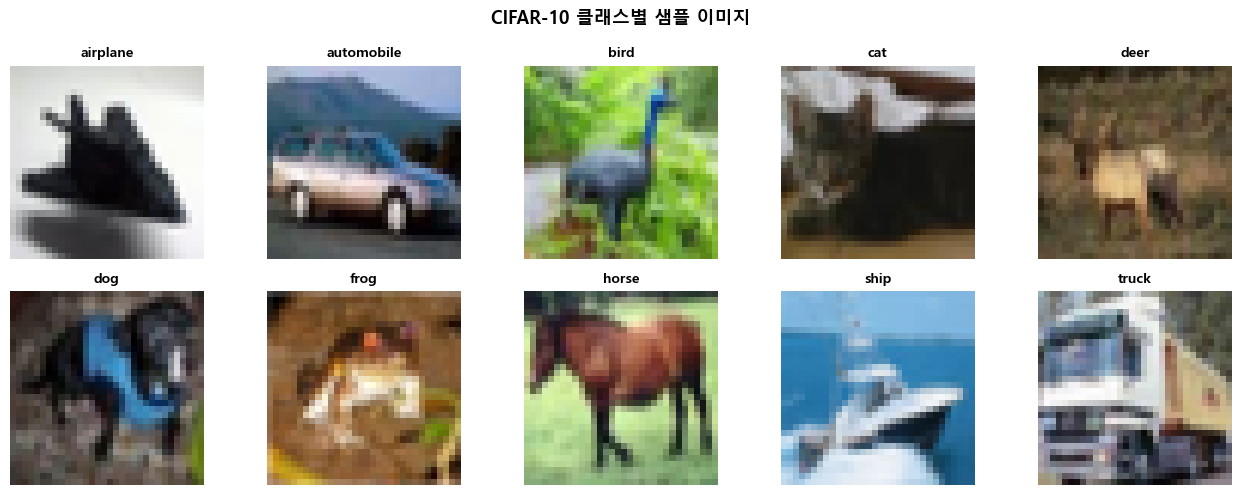

In [6]:
# ─────────────────────────────────────────────
# 1-2. 클래스별 샘플 시각화
# ─────────────────────────────────────────────
class_imgs = {}
for img, label in dataset_raw:
    if label not in class_imgs:
        class_imgs[label] = img
    if len(class_imgs) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for idx, (label, img) in enumerate(sorted(class_imgs.items())):
    axes[idx//5][idx%5].imshow(img)
    axes[idx//5][idx%5].set_title(CLASSES[label], fontsize=10, fontweight='bold')
    axes[idx//5][idx%5].axis('off')
plt.suptitle("CIFAR-10 클래스별 샘플 이미지", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 실습 2. 증강 기법 적용 전·후 비교

### 📖 데이터 증강이 왜 필요한가?

딥러닝 모델은 학습 데이터와 **비슷한** 데이터를 잘 예측합니다.  
학습 때 항상 정면 고양이 사진만 봤다면, 옆모습 고양이는 못 알아볼 수 있습니다.

증강(Augmentation)은 같은 이미지를 다양하게 변형하여 모델이 다양한 상황에 강건하도록 만듭니다.

| 증강 기법 | 효과 | 직관적 의미 |
|---|---|---|
| RandomCrop | 위치 불변성 | 고양이가 어디 있든 고양이다 |
| RandomHorizontalFlip | 방향 불변성 | 고양이가 왼쪽을 봐도 고양이다 |
| ColorJitter | 색상 불변성 | 어두운 곳에서 찍혀도 고양이다 |
| GaussianBlur | 해상도 불변성 | 흐릿하게 찍혀도 고양이다 |

> ⚠️ **주의**: 모든 증강이 모든 데이터셋에 좋은 건 아닙니다.  
> 숫자(MNIST)에 `RandomVerticalFlip`을 쓰면 6과 9를 구분 못하게 됩니다!

아래 코드를 실행하면 같은 이미지에 각 증강을 적용한 결과를 나란히 볼 수 있습니다.

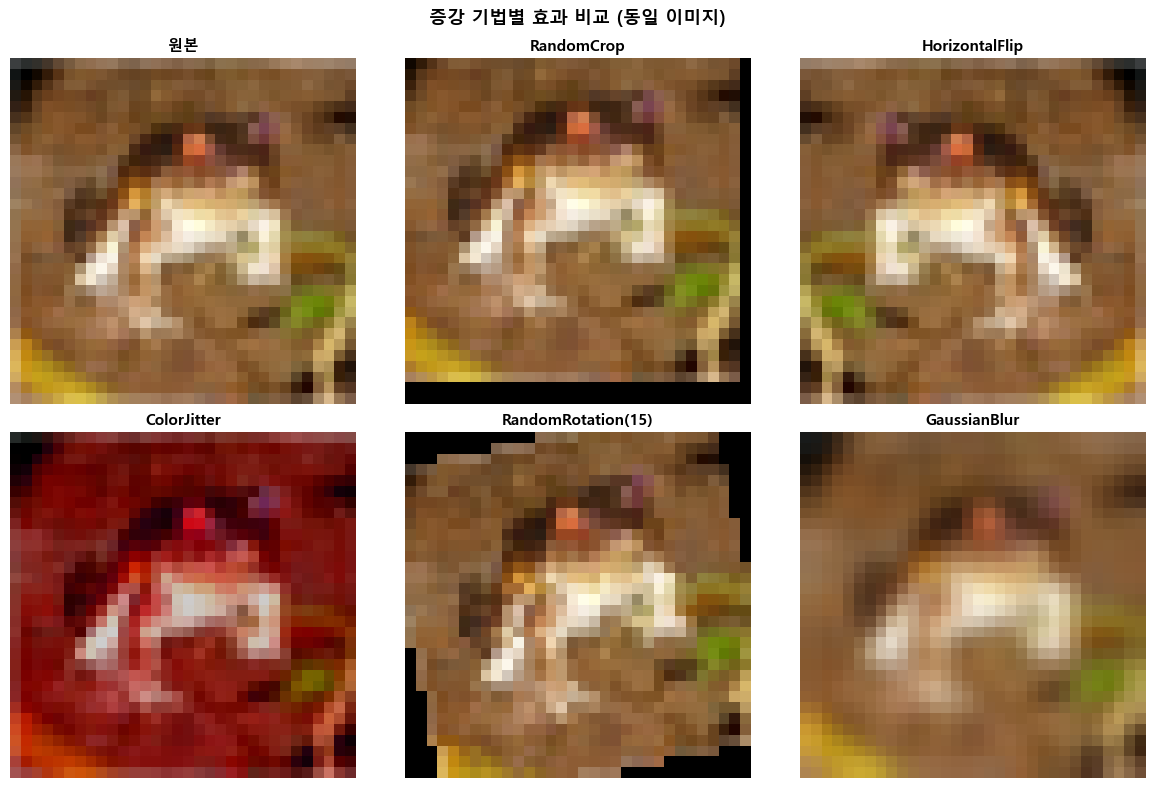

In [7]:
# ─────────────────────────────────────────────
# 2-1. 다양한 증강 변환 시각화
# ─────────────────────────────────────────────
sample_img = dataset_raw[0][0]  # PIL Image

augmentations = {
    "원본":               transforms.Compose([transforms.ToTensor()]),
    "RandomCrop":         transforms.Compose([transforms.RandomCrop(32, padding=4), transforms.ToTensor()]),
    "HorizontalFlip":     transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor()]),
    "ColorJitter":        transforms.Compose([transforms.ColorJitter(0.4,0.4,0.4,0.1), transforms.ToTensor()]),
    "RandomRotation(15)": transforms.Compose([transforms.RandomRotation(15), transforms.ToTensor()]),
    "GaussianBlur":       transforms.Compose([transforms.GaussianBlur(3, sigma=(0.1,2.0)), transforms.ToTensor()]),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (name, tfm) in zip(axes.ravel(), augmentations.items()):
    ax.imshow(tfm(sample_img).permute(1,2,0).clamp(0,1).numpy())
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.axis('off')
plt.suptitle("증강 기법별 효과 비교 (동일 이미지)", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 실습 3. 훈련/검증용 Transform 파이프라인 구성

### 📖 왜 훈련용과 검증용 transform이 달라야 하는가?

> 💡 **핵심 직관**  
> 증강은 "연습 중에 일부러 어렵게 만드는 것"입니다.  
> 시험(검증)을 어렵게 볼 필요는 없습니다. 공정한 기준으로 평가해야 합니다.

| 파이프라인 | 포함 변환 | 이유 |
|---|---|---|
| 훈련용 | RandomCrop + RandomFlip + ColorJitter + ToTensor + Normalize | 다양한 변형으로 과적합 방지 |
| 검증/테스트용 | **ToTensor + Normalize 만** | 일관된 기준으로 정확한 평가 |

> ⚠️ **자주 하는 실수**: 검증 데이터에도 랜덤 증강을 적용하면  
> 실행할 때마다 결과가 달라져 정확한 성능 평가가 불가능합니다.

### ✏️ TODO: 훈련용 / 검증용 transform 직접 구성
아래 두 파이프라인을 완성하세요.

In [ ]:
# ─────────────────────────────────────────────
# TODO: 훈련용 / 검증용 transform 직접 구성
# ─────────────────────────────────────────────

# 훈련용: 데이터 증강 포함
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),       # 위치 불변성
    transforms.RandomHorizontalFlip(),          # 좌우 대칭
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(___, ___)  # 힌트: CIFAR10_MEAN, CIFAR10_STD 변수를 사용하세요
])

# 검증/테스트용: 증강 없이 ToTensor + Normalize만
transform_val = transforms.Compose([
    ___,      # 힌트: PIL → Tensor 변환 (0~1)
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

print("transform_train:", transform_train)
print("\ntransform_val:", transform_val)

In [8]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])
print("✅ 정답 transform 로드 완료!")

✅ 정답 transform 로드 완료!


In [9]:
# ─────────────────────────────────────────────
# 3-1. 데이터셋 & DataLoader 구성
# ─────────────────────────────────────────────
train_full = CIFAR10('./data', train=True,  download=True, transform=transform_train)
test_set   = CIFAR10('./data', train=False, download=True, transform=transform_val)

from torch.utils.data import random_split, Subset
val_size = 5000
train_size = len(train_full) - val_size
train_set, val_set_raw = random_split(
    CIFAR10('./data', train=True, download=True, transform=transform_val),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
train_aug_set, _ = random_split(train_full, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader = DataLoader(train_aug_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_set_raw,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,      batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"훈련: {len(train_aug_set):,} / 검증: {len(val_set_raw):,} / 테스트: {len(test_set):,}")

훈련: 45,000 / 검증: 5,000 / 테스트: 10,000


---
## 실습 4. 증강 유무 성능 비교 실험

같은 모델·같은 데이터에서 **증강만 다르게** 적용하고 성능 차이를 측정합니다.

### 📖 실험 설계
```
조건 A (증강 없음): ToTensor + Normalize만 적용
조건 B (증강 있음): RandomCrop + RandomFlip + ColorJitter + ToTensor + Normalize

모델: 동일한 SimpleCIFARNet
학습: 동일한 하이퍼파라미터 (10 에포크, Adam, lr=0.001)
```

> 💡 **예상 결과**  
> 증강이 있는 모델은 처음에는 느리게 학습할 수 있지만,  
> 에포크가 쌓일수록 검증 정확도가 더 높아집니다.  
> 왜냐하면 "훈련 데이터에 과적합"되는 속도가 늦춰지기 때문입니다.

> ⚠️ **주의**: 이번 실험은 10 에포크 단기 비교입니다. 50 에포크 이상 학습하면 차이가 더 뚜렷하게 나타납니다.

### 📖 실험용 CNN 구조

이번 실험은 증강 효과 자체를 보는 것이 목적이므로,  
단순한 2-block CNN을 사용합니다. 모델 구조보다 데이터 전처리의 영향에 집중하세요.

```
입력 (3, 32, 32)
→ Conv×2 → BN → ReLU → MaxPool → Dropout  # (32채널, 16×16)
→ Conv×2 → BN → ReLU → MaxPool → Dropout  # (64채널, 8×8)
→ Flatten → Linear(512) → Dropout → Linear(10)
```

In [10]:
# ─────────────────────────────────────────────
# 4-1. 간단한 CNN 정의 (비교 실험용)
# ─────────────────────────────────────────────
class SimpleCIFARNet(nn.Module):
    """CIFAR-10 실험용 간단한 CNN.
    입력: (N, 3, 32, 32) → 출력: (N, 10)"""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 512), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(512, 10)
        )
    def forward(self, x): return self.classifier(self.features(x))

In [15]:
def run_training(model, train_loader, val_loader, epochs=10, lr=0.001):
    """모델 학습 후 history 반환."""
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss":[], "val_acc":[]}
    for epoch in range(epochs):
        model.train()
        tl = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            loss = crit(model(imgs), labels)
            loss.backward(); opt.step()
            tl += loss.item()
        model.eval(); correct = total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = model(imgs).argmax(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)
        hist["train_loss"].append(tl/len(train_loader))
        hist["val_acc"].append(correct/total)
        if (epoch+1) % 2 == 0:
            print(f"  Epoch {epoch+1:2d} | Val Acc: {correct/total*100:.2f}%")
    return hist

In [18]:
# ─────────────────────────────────────────────
# 4-2. 증강 없음 모델 학습 (No Aug)
# ─────────────────────────────────────────────
train_noaug = DataLoader(
    CIFAR10('./data', True, download=True, transform=transform_val),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

print("=== 증강 없음 학습 ===")
model_noaug = SimpleCIFARNet().to(device)
hist_noaug = run_training(model_noaug, train_noaug, val_loader, epochs=20)

=== 증강 없음 학습 ===
  Epoch  2 | Val Acc: 71.54%
  Epoch  4 | Val Acc: 78.10%
  Epoch  6 | Val Acc: 83.06%
  Epoch  8 | Val Acc: 84.90%
  Epoch 10 | Val Acc: 88.76%
  Epoch 12 | Val Acc: 89.60%
  Epoch 14 | Val Acc: 92.28%
  Epoch 16 | Val Acc: 94.32%
  Epoch 18 | Val Acc: 95.94%
  Epoch 20 | Val Acc: 95.98%


In [16]:
# ─────────────────────────────────────────────
# 4-3. 증강 있음 모델 학습 (With Aug)
# ─────────────────────────────────────────────
print("=== 증강 적용 학습 ===")
model_aug = SimpleCIFARNet().to(device)
hist_aug = run_training(model_aug, train_loader, val_loader, epochs=20)

=== 증강 적용 학습 ===
  Epoch  2 | Val Acc: 57.24%
  Epoch  4 | Val Acc: 69.04%
  Epoch  6 | Val Acc: 72.20%
  Epoch  8 | Val Acc: 74.82%
  Epoch 10 | Val Acc: 76.98%
  Epoch 12 | Val Acc: 77.10%
  Epoch 14 | Val Acc: 79.44%
  Epoch 16 | Val Acc: 80.16%
  Epoch 18 | Val Acc: 80.30%
  Epoch 20 | Val Acc: 80.98%


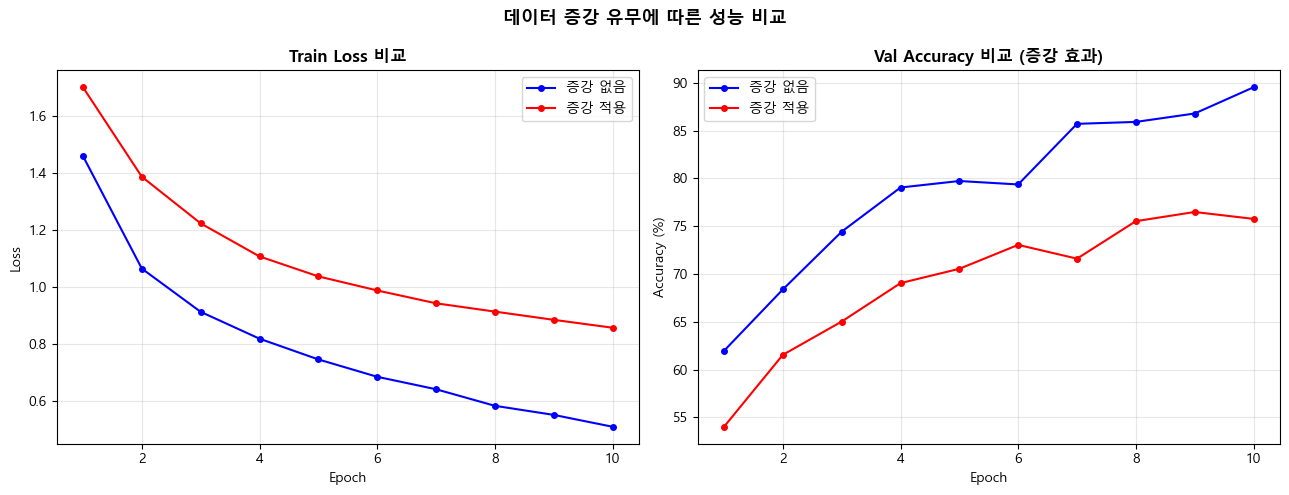


최종 검증 정확도:
  증강 없음: 89.52%
  증강 적용: 75.76%
  차이:    -13.76%p


In [14]:
# ─────────────────────────────────────────────
# 4-4. 증강 효과 비교 시각화
# ─────────────────────────────────────────────
epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs, hist_noaug["train_loss"], 'b-o', markersize=4, label="증강 없음")
axes[0].plot(epochs, hist_aug["train_loss"],   'r-o', markersize=4, label="증강 적용")
axes[0].set_title("Train Loss 비교", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in hist_noaug["val_acc"]], 'b-o', markersize=4, label="증강 없음")
axes[1].plot(epochs, [a*100 for a in hist_aug["val_acc"]],   'r-o', markersize=4, label="증강 적용")
axes[1].set_title("Val Accuracy 비교 (증강 효과)", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("데이터 증강 유무에 따른 성능 비교", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n최종 검증 정확도:")
print(f"  증강 없음: {hist_noaug['val_acc'][-1]*100:.2f}%")
print(f"  증강 적용: {hist_aug['val_acc'][-1]*100:.2f}%")
print(f"  차이:    {(hist_aug['val_acc'][-1]-hist_noaug['val_acc'][-1])*100:.2f}%p")

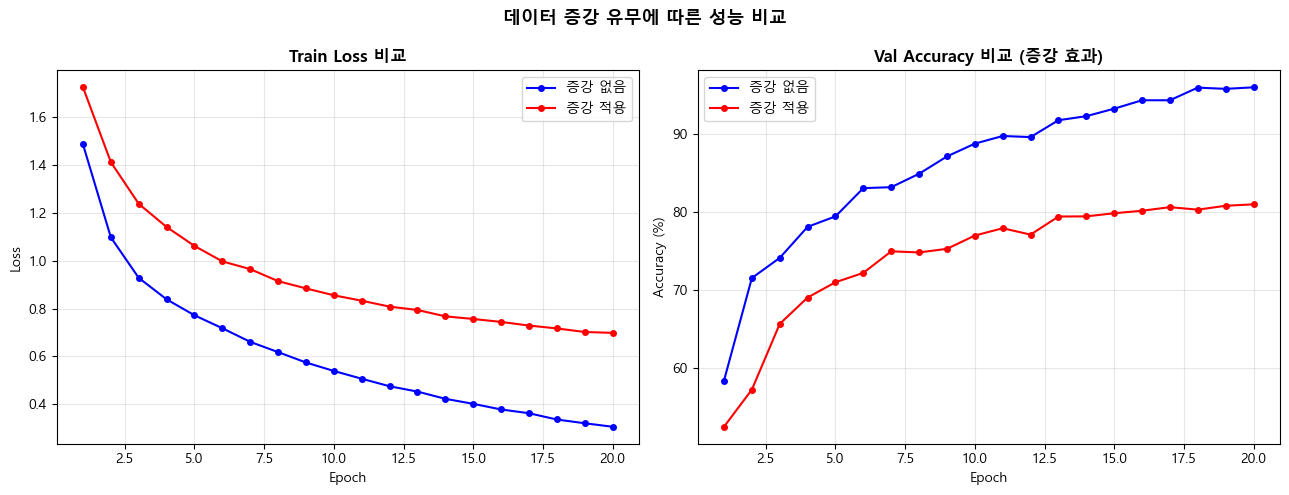


최종 검증 정확도:
  증강 없음: 95.98%
  증강 적용: 80.98%
  차이:    -15.00%p


In [19]:
# ─────────────────────────────────────────────
# 4-4. 증강 효과 비교 시각화
# ─────────────────────────────────────────────
epochs = range(1, 21)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs, hist_noaug["train_loss"], 'b-o', markersize=4, label="증강 없음")
axes[0].plot(epochs, hist_aug["train_loss"],   'r-o', markersize=4, label="증강 적용")
axes[0].set_title("Train Loss 비교", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in hist_noaug["val_acc"]], 'b-o', markersize=4, label="증강 없음")
axes[1].plot(epochs, [a*100 for a in hist_aug["val_acc"]],   'r-o', markersize=4, label="증강 적용")
axes[1].set_title("Val Accuracy 비교 (증강 효과)", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("데이터 증강 유무에 따른 성능 비교", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n최종 검증 정확도:")
print(f"  증강 없음: {hist_noaug['val_acc'][-1]*100:.2f}%")
print(f"  증강 적용: {hist_aug['val_acc'][-1]*100:.2f}%")
print(f"  차이:    {(hist_aug['val_acc'][-1]-hist_noaug['val_acc'][-1])*100:.2f}%p")

---
## 🚀 도전 과제

### 과제 1. 정규화 효과 히스토그램
정규화 전·후 픽셀값 분포를 채널별로 히스토그램으로 비교하세요.

```python
# 힌트
img_tensor = transforms.ToTensor()(sample_img)  # 정규화 전
img_normalized = transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)(img_tensor)
```

### 과제 2. AutoAugment 적용
`transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.CIFAR10)`을 훈련 파이프라인에  
추가하고 성능 차이를 비교하세요.

### 과제 3. Cutout / MixUp 증강
Cutout(이미지 일부 마스킹)을 구현하고 기존 증강 대비 성능을 비교하세요.
